# **0. - Large Language Models**

Durante la década de 2020, la IA experimentó un boom debido a los transformers y LLMs. Los LLMs son modelos de lenguaje basados en redes neuronales capaces de generar texto pudiendo resolver

## **Caso de Éxito: OpenAI**

Hasta entonces, la IA se aplicaba, no se vendía. OpenAI ha sido la primera empresa capaz de crear lo que se denomina "modelo fundacional" (modelo capaz de resolver cualquier problema de lenguaje general a partir de un contexto). Esto ha permitido comercialiar directamente la IA como servicio.

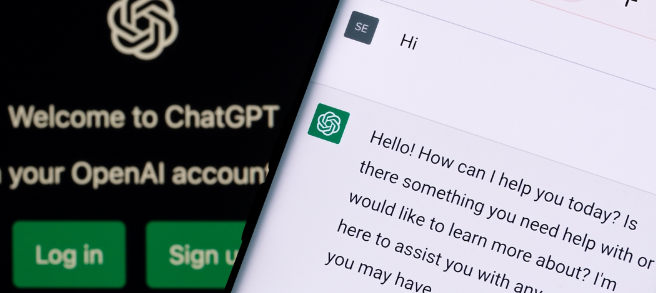

# **1. - Large Language Models**

Los large language models son modelos de lenguaje basados en redes de neuronas. Existen diferentes formas de implementar modelos de lenguaje con redes de neuronas. En particular basadas en una implementación denominada **transformers**

## **1.1. - Introducción**

### Transformer Embeddings

**Tokenizador BPE**

La principal ventaja de este tokenizador es que contruye un vocabulario a partir de "conglomerar" caracteres (similar a los ngramas). Esto permite que sea capaz de aprender "clusters de palabras" al mismo teimpo que nunca tenga el problema de out-of-vocabulary (OOV).

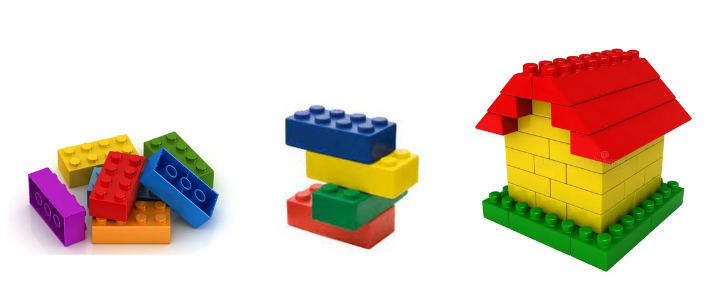

**Token Embeddings**

No usamos embeddings preconstruidos como word2vec, sino que los embeddings forman parte del modelo. Esto quiere decir que se "aprenden" a la vez que la red aprende a generar textos

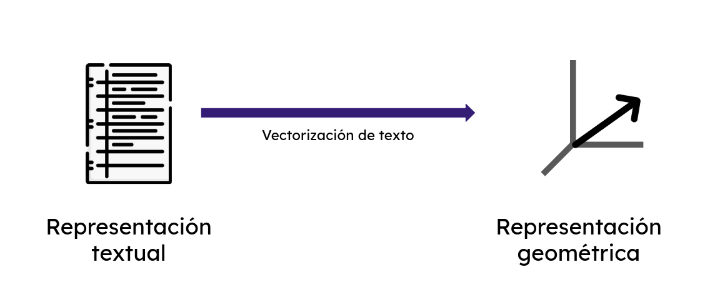

**Possitional Embeddings**

Además de los embeddings de palabra, también se constryue un embedding de posición. Este embedding le atribuye un valor a cada palabra en base a la posición que ocupa dentro del contexto. Esto ayuda a entender mejor la estructura del lenguaje.

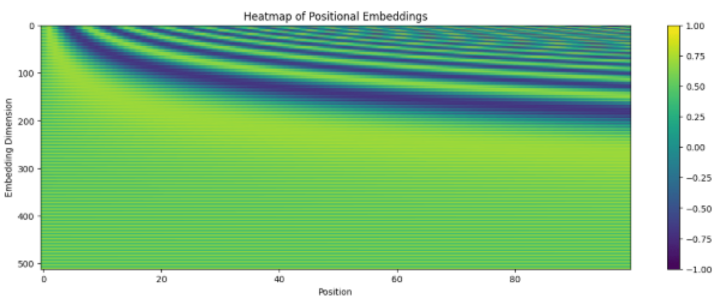

### Attention Mechanism

**N-gramas**

Los modelos de lenguaje basados en n-gramas tienen el problema de que no funcionan bien cuando empiezan a trabajar con contextos relativamente grandes, ya que solo tienen en cuenta los últimos n-gramas

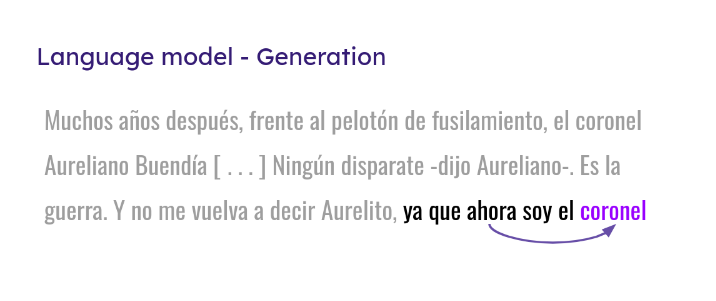

**Attention Mask**

Los transformers tienen la ventaja de trabajar con ventanas de contexto más grandes. Al mismo tiempo, para fijarse solo en las partes importantes, tienen algo que se denomina "attention mask" que permite que se fijen solo en las partes relevantes

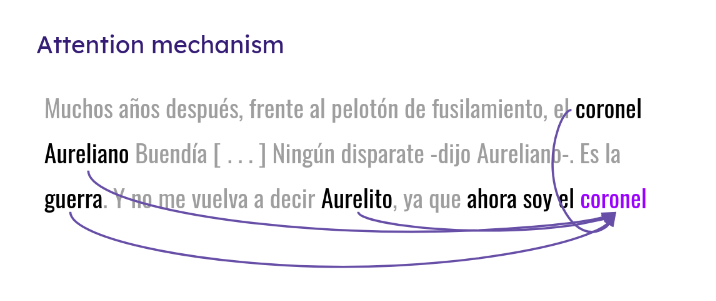

**Attention embeddings vs Word2vec**


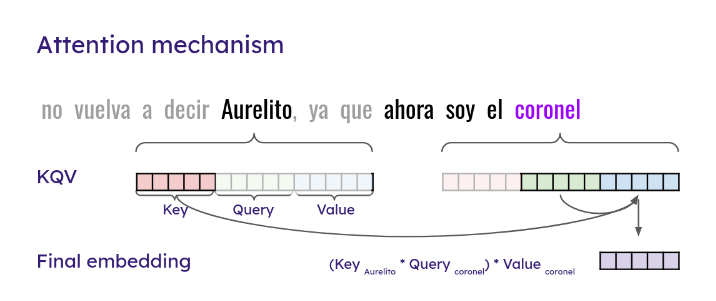

**Multiheaded Attention**

En la práctica no se aplica una única máscara de atención sobre los embeddings sino que se aplican varias en paralelo. Esto se denomina "multiheaded".

### Multilayer Perceptron

**Transformer Block**

Después de las máscaras de atención se aplica una normalización y una red neuronal. El conjunto de estas 3 componentes es lo que se denomina "transformer block". Un modelo de tipo transformer suele tener varios transformer block en paralelo

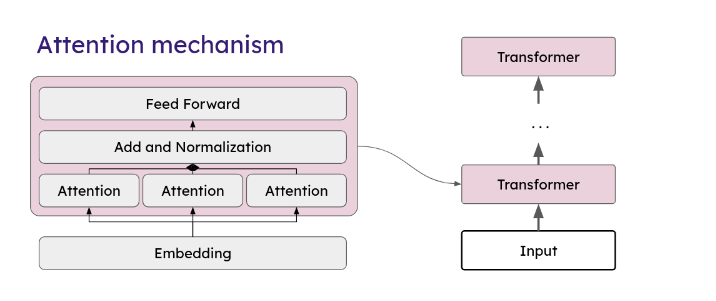

**Token Outputs**

Después del último transformer se añade una capa densa con dimensión igual al tamaño del vocabulario. De manera que cada salida se corresponde con la probabilidad de cada palabra

> **NOTA**: Para más imformación leer la siguiente deocumentación
> * [Transformers Explained](https://poloclub.github.io/transformer-explainer/)
> * [Illustrated GPT2](https://jalammar.github.io/illustrated-gpt2/)

## **1.2. - Desarrollo de GPT**

In [1]:
# !pip install -q tensorflow
# !pip install -q keras_hub
# !pip install -q tensorflow_text

import os
import keras
import keras_hub
import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TF logs

### Dataset - SimpleBooks from Gutemberg

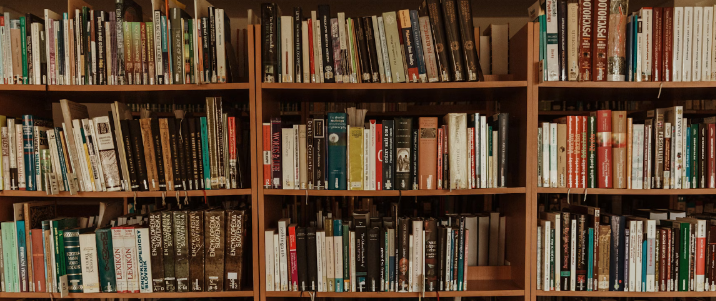

**SimpleBooks** es un corpus de libros de gutemberg project, creado específicamente para problemas de lenguaje. Su peculiaridad es que apesar de tener bastante volumen de documentos, el vocabulario es relativamente pequeño, simplificando el desarrollo y entrenamiento de redes de neuronas

In [6]:
!wget -q https://dldata-public.s3.us-east-2.amazonaws.com/simplebooks.zip -O /tmp/simplebooks.zip
!unzip -qo /tmp/simplebooks.zip -d /tmp
!cp /tmp/simplebooks/simplebooks-92-raw/train.txt /tmp/simplebooks.txt
!head -n 30 /tmp/simplebooks.txt

Dave Darrin's Second Year At Annapolis

Or

Two Midshipmen As Naval Academy "Youngsters"

By

H. Irving Hancock



Chapter I

A Question Of Midshipman Honor

"How can a midshipman and gentleman act in that way?"

The voice of Midshipman David Darrin, United States Navy, vibrated uneasily as he turned to his comrades.

"It's a shame -- that's what it is," quivered Mr. Farley, also of the third class at the United States Naval Academy.

"But the question is," propounded Midshipman Dan Dalzell, "what are we going to do about it?"

"Is it any part of our business to bother with the fellow?" demanded Farley half savagely.

Now Farley was rather hot-tempered, though he was "all there" in points that involved the honor of the brigade of midshipmen.

Five midshipmen stood in the squalid, ill-odored back room of a Chinese laundry in the town of Annapolis.



In [3]:
import requests


MIN_LEN = 64
SEQ_LEN = 128  # Length of training sequences, in tokens
MAX_LEN = 256
BATCH_SIZE = 64


with open("/tmp/simplebooks.txt", "r") as f:
    corpus = f.read()


### **Preprocesamiento**

**Filtrado**

Filtramos el dataset para quedarnos únicamente con texto que contienen principalmente las palabras más usadas de de inglés.

In [10]:
response = requests.get("https://raw.githubusercontent.com/powerlanguage/word-lists/refs/heads/master/1000-most-common-words.txt")
english_most_common_words = response.text.split("\n")

def filter(corpus):

    corpus = corpus.split("\n\n")

    # Nos quedamos solo con textos que no sean demasiado cortos
    corpus = [line for line in corpus if len(line.split(' ')) >= MIN_LEN]

    # Nos quedamos solo con textos que tengan un 80% de palabras comunes
    corpus = [line for line in corpus if sum(word in english_most_common_words for word in line.split(' '))>0.8]

    corpus = "\n\n".join(corpus)

    return corpus

corpus = filter(corpus)

with open("/tmp/train.txt", "w") as f:
    f.write(corpus)

**Preprocesamiento**

Después del filtrado hacemos un preprocesamiento para simplificar el texto

In [16]:
import regex

MIN_LEN = 64
SEQ_LEN = 128  # Length of training sequences, in tokens
MAX_LEN = 256
BATCH_SIZE = 64


with open("/tmp/train.txt", "r") as f:
    corpus = f.read()

def preprocess(text):

    # Eliminamos símbolos
    text = text.replace(r"[\[\{]","(")
    text = text.replace(r"[\]\}]",")")
    text = text.replace(";",".")
    text = text.replace("'",'"')

    # Eliminamos acentos
    text = regex.sub(r'[áàâãäå]', 'a', text)
    text = regex.sub(r'[éèêë]', 'e', text)
    text = regex.sub(r'[íìîï]', 'i', text)
    text = regex.sub(r'[óòôõö]', 'o', text)
    text = regex.sub(r'[úùûü]', 'u', text)

    # Minúsculas
    text = text.lower()

    return text

corpus_preprocessed = []
for text in corpus.split("\n\n"):
    corpus_preprocessed.append(text)


corpus_preprocessed = "\n".join(corpus_preprocessed)

with open("/tmp/train.txt", "w") as f:
    f.write(corpus_preprocessed)

**Creamos el corpus**

A partir del dataset creamos un corpus listo para entrenar el modelo. Los dataset en Keras se crean a partir de un archivo en disco

In [19]:
corpus = (
    tf.data.TextLineDataset("/home/train.txt")
    .shuffle(buffer_size=BATCH_SIZE * 4)
    .batch(BATCH_SIZE)
)


batch = corpus.as_numpy_iterator().next()
sample = batch[0]
print(sample.decode("utf-8"))

Outside the sleigh-bells sounded enticing. It was the first sleighing of the season. Mabel and Ben had been off for a ride, and Arna and Hazen, too. How Peggy longed to be skimming over the snow instead of polishing knives all alone in the kitchen. Sue Cummings came that afternoon to invite Peggy to her party, given in Esther's honour. Sue enumerated six other gatherings that were being given that week in honour of Esther's visit home. Sue seemed to dwell much on the subject. Presently Peggy, with hot cheeks, understood why. Everybody was giving Esther a party, everybody but Peggy herself. Esther's own chum, and all the other girls, were talking about it.


### Tokenizer

**Vocabulario**

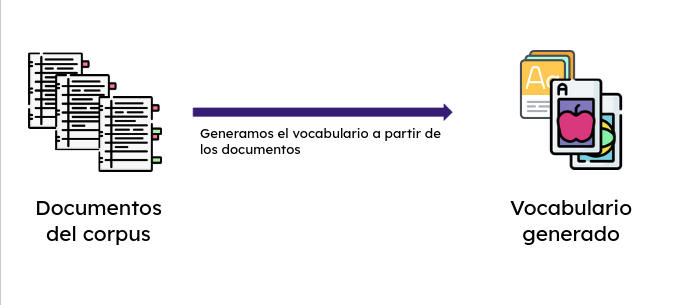

In [20]:
VOCAB_SIZE = 5000

vocab = keras_hub.tokenizers.compute_word_piece_vocabulary(
    data=corpus,
    vocabulary_size=VOCAB_SIZE,
    reserved_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"],
    split_on_cjk=False,
)

print("Vocabulary size", len(vocab))
print(vocab[0:300])

Vocabulary size 4974
['[PAD]', '[UNK]', '[BOS]', '[EOS]', '!', '"', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '=', '>', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', '\\', ']', '^', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '}', '~', '¢', '£', '°', 'À', 'Â', 'Ã', 'É', 'Ö', 'à', 'á', 'â', 'ä', 'å', 'ç', 'è', 'é', 'ê', 'ë', 'ì', 'í', 'î', 'ï', 'ñ', 'ò', 'ó', 'ô', 'ö', 'ù', 'ú', 'û', 'ü', 'č', 'ę', '—', 'the', 'and', 'to', 'of', 'in', 'was', 'that', 'he', '##s', 'had', 'it', 'his', 'for', 'as', 'with', 'on', 'her', 'they', 'you', 'at', 'not', 'be', 'were', 'but', 'him', 'she', 'is', 'The', 'have', 'all', '##ing', 'them', 'so', 'from', '##ed', 'by', 'would', 'which', 'their', 'one', 'up', 'we', 'out', 'this', 'when', 'b

**Tokenizador**

Usamos un tokenizador WordPiece (similar al tokenizador BPE pero con N-gramas de caracteres con word boundaries)

In [21]:
tokenizer = keras_hub.tokenizers.WordPieceTokenizer(
    vocabulary=vocab,
    sequence_length=SEQ_LEN,
)

sample_tokens = tokenizer(sample)
for token in sample_tokens[0:20]:
  print(int(token),"\t",vocab[token])

47 	 O
2945 	 ##uts
1184 	 ##ide
128 	 the
82 	 s
396 	 ##le
2858 	 ##igh
15 	 -
4044 	 bells
2393 	 sounded
1411 	 en
1538 	 ##tic
158 	 ##ing
16 	 .
189 	 It
133 	 was
128 	 the
249 	 first
82 	 s
396 	 ##le


**Tokenización**

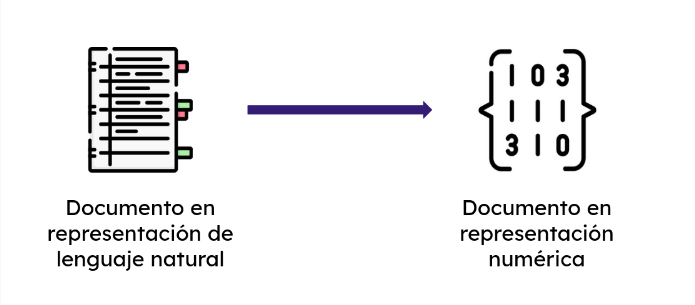

In [ ]:
def tokenize(text):

    # Tokenizamos el texto
    token_ids = tokenizer(text)

    # Añadimos el token [BOS] al principio de la frase
    x =  keras_hub.layers.StartEndPacker(
        sequence_length=SEQ_LEN,
        start_value=tokenizer.token_to_id("[BOS]"),
        pad_value=tokenizer.token_to_id("[PAD]"),
    )(token_ids)

    # El la misma frase sin el [BOS] (o sea, el tarjet de cada palabra es la siguiente)
    y =  keras_hub.layers.StartEndPacker(
        sequence_length=SEQ_LEN,
        end_value=tokenizer.token_to_id("[EOS]"),
        pad_value=tokenizer.token_to_id("[PAD]"),
    )(token_ids)

    return x, y


# Tokenize and split into train and label sequences.
corpus_tokenized = corpus.map(tokenize).prefetch(tf.data.AUTOTUNE)

In [ ]:
one_batch = next(iter(corpus_tokenized))
print(one_batch)

(<tf.Tensor: shape=(64, 128), dtype=int32, numpy=
array([[   2, 1155,  203, ...,  183,   14,    5],
       [   2,  155,  979, ...,   66, 4317, 2731],
       [   2,  295, 3908, ...,    0,    0,    0],
       ...,
       [   2, 4363,  743, ...,    0,    0,    0],
       [   2,  268,  133, ...,    0,    0,    0],
       [   2,  189,  133, ...,   81, 1485,  196]], dtype=int32)>, <tf.Tensor: shape=(64, 128), dtype=int32, numpy=
array([[1155,  203, 4551, ...,   14,    5,    3],
       [ 155,  979,  154, ..., 4317, 2731,    3],
       [ 295, 3908,  153, ...,    0,    0,    3],
       ...,
       [4363,  743,  199, ...,    0,    0,    3],
       [ 268,  133,  185, ...,    0,    0,    3],
       [ 189,  133,   64, ..., 1485,  196,    3]], dtype=int32)>)


### Model

**Parámetros**

Los parámetros que tiene GPT3 para estos parámetros son los siguientes (el primer chatGPT que salió)

In [ ]:
NUM_LAYERS = 96              # Transformer blocks
NUM_HEADS = 96               # Attention heads
EMBED_DIM = 12288            # d_model
FEED_FORWARD_DIM = 49152     # 4 * EMBED_DIM

Los parámetros que vamos a usar para nuestraversión "lite" son los siguientes

In [ ]:
NUM_HEADS = 3
NUM_LAYERS = 2
EMBED_DIM = 256
FEED_FORWARD_DIM = 128

**Embeddings**

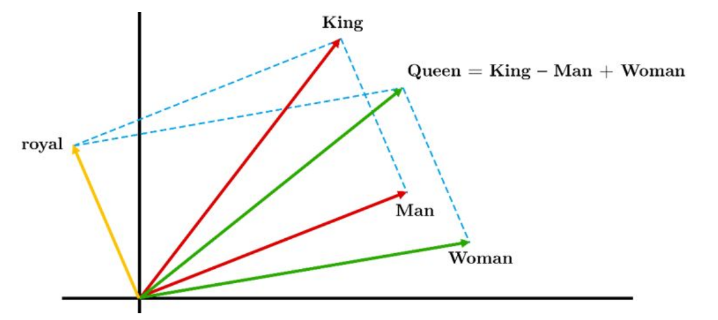

In [ ]:
inputs = keras.layers.Input(shape=(None,), dtype="int32")

# Embedding
x = keras_hub.layers.TokenAndPositionEmbedding(
    vocabulary_size=len(vocab),
    sequence_length=SEQ_LEN,
    embedding_dim=EMBED_DIM,
)(inputs)

**Transformers**

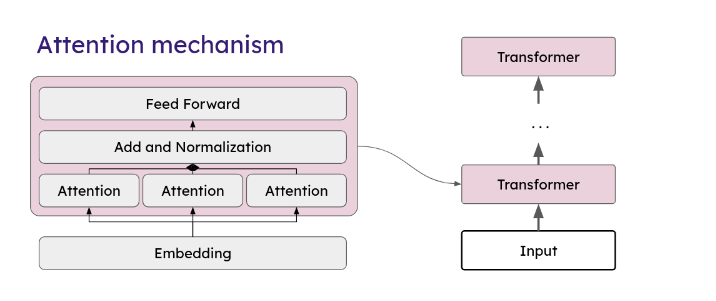

In [ ]:
# Transformer decoders.
for _ in range(NUM_LAYERS):
    x = keras_hub.layers.TransformerDecoder(
        num_heads=NUM_HEADS,
        intermediate_dim=FEED_FORWARD_DIM,
        activation='relu',
    )(x)  # Pass the mask to the call method


**Output**

In [ ]:
# Output.
outputs = keras.layers.Dense(len(vocab))(x)

**Loss y optimizador**

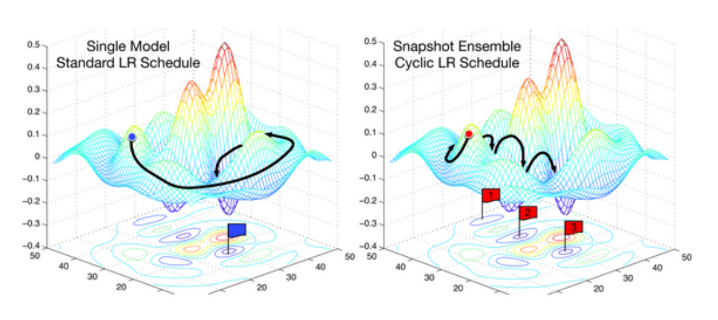

In [ ]:
model = keras.Model(inputs=inputs, outputs=outputs)

loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
perplexity = keras_hub.metrics.Perplexity(from_logits=True, mask_token_id=0)

model.compile(
    optimizer="adam",
    loss=loss_fn,
    metrics=[perplexity],
)

# Explicitly build the model to create all variables before training
model.build((BATCH_SIZE, SEQ_LEN))

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, None, 256)      │     1,306,112 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder             │ (None, None, 256)      │       329,085 │
│ (TransformerDecoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder_1           │ (None, None, 256)      │       329,085 │
│ (TransformerDecoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 4974)     │     1,278,318 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,242,600 (12.37 MB)

 Trainable params: 3,242,600 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

In [ ]:
history = model.fit(corpus_tokenized, epochs=5)

Epoch 1/5
   5411/Unknown 291s 52ms/step - loss: 4.1113 - perplexity: 114.4911

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


5411/5411 ━━━━━━━━━━━━━━━━━━━━ 292s 52ms/step - loss: 4.1113 - perplexity: 114.4829
Epoch 2/5
5411/5411 ━━━━━━━━━━━━━━━━━━━━ 276s 51ms/step - loss: 3.5356 - perplexity: 51.8384
Epoch 3/5
5411/5411 ━━━━━━━━━━━━━━━━━━━━ 275s 51ms/step - loss: 3.4440 - perplexity: 46.7985
Epoch 4/5
5411/5411 ━━━━━━━━━━━━━━━━━━━━ 275s 51ms/step - loss: 3.3933 - perplexity: 44.2188
Epoch 5/5
5411/5411 ━━━━━━━━━━━━━━━━━━━━ 276s 51ms/step - loss: 3.3584 - perplexity: 42.5321


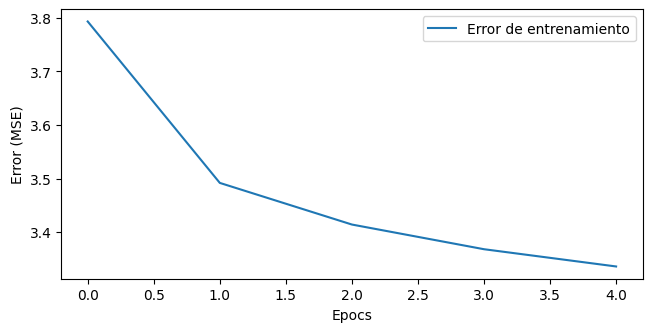

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [7.5, 3.5]

# Grafica
plt.plot(history.history['loss'], label='Error de entrenamiento')
plt.xlabel('Epocs')
plt.ylabel('Error (MSE)')
plt.legend()
plt.show()

## **1.3. Generación con GPT**

### Prompt

In [ ]:
start_packer = keras_hub.layers.StartEndPacker(
    sequence_length=SEQ_LEN,
    start_value=tokenizer.token_to_id("[BOS]"),
)

prompt_text = "once a long time ago"
prompt_tokens = start_packer(tokenizer([prompt_text]))
prompt_length = int(keras.ops.sum(keras.ops.cast(prompt_tokens != 0, "int32")))
prompt_tokens

<tf.Tensor: shape=(1, 128), dtype=int32, numpy=
array([[  2, 285,  64, 239, 190, 911,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]],
      dtype=int32)>

### **Top K / Top P**

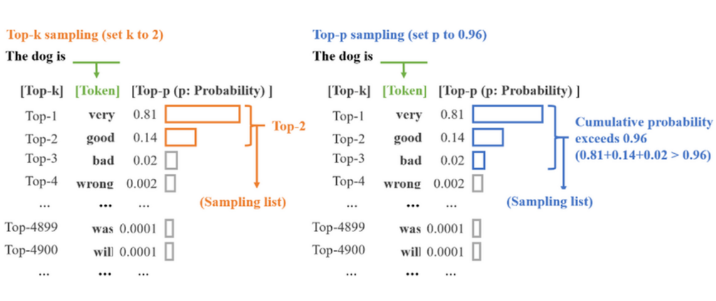

Para que las respuestas del modelo no sean siempre las mismas, se suelen usar diferentes técnicas para hacer las respusetas más aleatorias

In [ ]:
def generate_next(prompt, cache, index):
    # index represents the position we are currently generating.
    # We want the prediction based on all tokens BEFORE index.
    logits = model(prompt)

    # Grab the logits for the token immediately preceding the current index
    logits = logits[:, index - 1, :]
    unk_id = tokenizer.token_to_id("[UNK]")
    logits = keras.ops.scatter_update(
        logits,
        [[0, unk_id]],
        [-float("inf")]
    )

    return logits, None, cache

In [ ]:
sampler = keras_hub.samplers.TopPSampler(p=0.9)

for i in range(1,6):
    output_tokens = sampler(
        next=generate_next,
        prompt=prompt_tokens,
        index=prompt_length, # Start generating AFTER the prompt
    )

    txt = tokenizer.detokenize(output_tokens)[0]
    print(f"Generated text {i}: \n{txt}\n\n")

Generated text 1: 
[BOS] once a long time ago they found in her vigorous condition , and in acigator , there was a truck in a pool , at the house which filled the air with sad - looking eyes and horror , or some red boar , boar and cake , which is rolled into a green place . Then Coler fell , and brought a lion and wild wit acid was wound . A whole family had buried by the old man , and with a little danged arm , the pirates , for the marilla , was a well as yet they had been spw


Generated text 2: 
[BOS] once a long time ago , it was hard . Beyond the Earl of The Singine of Leges ' station where you could see casket above the east of the Braway of Winter , which you wrote from the infactors of the Old Towers , for the time of late fighting at the Green Church had learned the interest to be in the weather - breaker ' s force . The conversation of the Red - side of the school came to with the reports of success . [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [

### **Temperature**

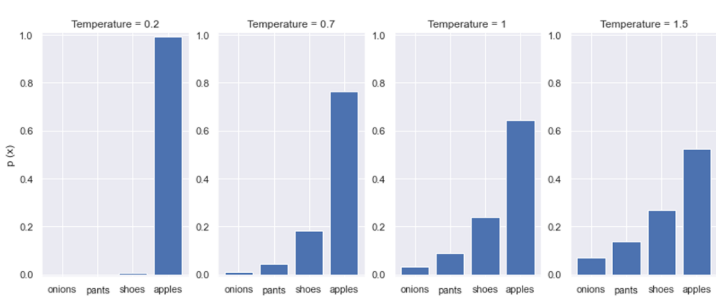

A veces no solamente queremos aleatorizar las respuestas, sino que la probabilidad de lso tokens "más probables" no sea tan alta. A esto es a lo que se le llama temperatura

In [ ]:
def generate_next(prompt, cache, index):
    # index represents the position we are currently generating.
    # We want the prediction based on all tokens BEFORE index.
    logits = model(prompt)

    # A menor temperatura, respuestas más "imaginativas"
    temperature = 0.4
    logits = logits / temperature
    logits = keras.ops.softmax(logits)


    # Grab the logits for the token immediately preceding the current index
    logits = logits[:, index - 1, :]
    unk_id = tokenizer.token_to_id("[UNK]")
    logits = keras.ops.scatter_update(
        logits,
        [[0, unk_id]],
        [-float("inf")]
    )

    return logits, None, cache

In [ ]:
sampler = keras_hub.samplers.TopPSampler(p=0.9)

for i in range(1,6):
    output_tokens = sampler(
        next=generate_next,
        prompt=prompt_tokens,
        index=prompt_length, # Start generating AFTER the prompt
    )

    txt = tokenizer.detokenize(output_tokens)[0]
    print(f"Generated text {i}: \n{txt}\n\n")

Generated text 1: 
[BOS] once a long time ago cheerful leap southferred 000 Rose f everywhere cousin rode level gazegar end toird imagine preciousially Marjorierch eyeora alarm shoutingul meal scout hanging stockfined bid skill Dianath claimless already Do series messenger back bark an lest region instantly shore merry decide Where crept New tables trade play flew hit meanshs mill believeised holdteenc fatesieipped Mother managed moment medicine safety box railroad 1 want built shadowlies load liked opposite corn wonderful natureix tore Thomas daring S creek the topsign vast overz serve show Menpressed waste we cannot patchaming nearly fruit missed rest supposed approached return fell invitation Was But exposed shown Each


Generated text 2: 
[BOS] once a long time ago dutyvised ranks corn brokenpin directed gained kind comfortablerhamrine settleuishep White - buffalo sought swam either close wrong Still hardly movements east loadrewze pressed Katy delivered fears require friend grow e

---

# **2. Chat / Instruction Models**

Aunque ya hemos visto cómo se crea un LLM para que sea capaz de generar texto, la realidad es que los modelos de lenguaje no se usan para generar texto sino para seguir conversaciones y/o seguir instrucciones. En esta sección vamos a hablar de ello

## **2.1. - Introducción**

### Instruct Dataset


La diferencia entre los modelos de lenguaje como GPT y los chatbots capaces de entrender instrucciones y seguiconversaciones como ChatGPT, no está en el modelo, sino que está en los datos. Según cómo se definan existen diferentes tipos datasets. Algunas de los tipos/características que suele tener son las siguientes

**Roles**

Dataset donde los registros son conversaciones en los que cada registro tiene una parte de la conversación y quién lo ha dicho (e.g. [Ultrachat](https://huggingface.co/datasets/HuggingFaceH4/ultrachat_200k)

```json
[
  {
    "content": "The function \\( g(x) \\) satisfies the functional equation\n\\[ g(x + y) = g(x) + g(y) \\]\nfor all real numbers \\( x \\) and \\( y \\), and it is given that \\( g(3) = 4 \\). Find \\( g(10) \\).",
    "role": "user"
  },
  {
    "content": "Given the functional equation and the specific value \\( g(3) = 4 \\), we can find \\( g(1) \\) by using the equation multiple times:\n\\[\ng(3) = g(2) + g(1)\n\\]\n\\[\ng(2) = g(1) + g(1) = 2g(1)\n\\]\nThus,\n\\[\n4 = 2g(1) + g(1) = 3g(1)\n\\]\n\\[\ng(1) = \\frac{4}{3}\n\\]\nNow we can find \\( g(10) \\) using \\( g(1) \\):\n\\[\ng(10) = 10g(1) = 10 \\times \\frac{4}{3} = \\frac{40}{3}\n\\]\nHence, the value of \\( g(10) \\) is \\(\\boxed{\\frac{40}{3}}\\).",
    "role": "assistant"
  }
]
```

**Instruction**

Datasets orientados a resolver instrucciones. Los registros contienen el tipo de instrucción, los inputs y la respuesta esperada (e.g. [Alpaca](https://huggingface.co/datasets/tatsu-lab/alpaca))

```json
{
    "instruction": "Create a classification task by clustering the given list of items.",
    "input": "Apples, oranges, bananas, strawberries, pineapples",
    "output": "Class 1: Apples, Oranges\nClass 2: Bananas, Strawberries\nClass 3: Pineapples",
    "text": "Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.\n\n### Instruction:\nCreate a classification task by clustering the given list of items.\n\n### Input:\nApples, oranges, bananas, strawberries, pineapples\n\n### Response:\nClass 1: Apples, Oranges\nClass 2: Bananas, Strawberries\nClass 3: Pineapples",
}
```

**Reasoning**

Dataset en los que no solo se le pone la respuesta sino el razonamiento para llegar a la respuesta (p.e. [OpenThoughts](https://huggingface.co/datasets/open-thoughts/OpenThoughts-114k))

```txt
Prompt:
¿Cuántos años tiene Ana?
[(datos)]

Razonamiento:
Paso 1...
Paso 2...
Respuesta final: 27
```

### Fine Tuning

Muchas veces queremos entrenar un modelo sobre un dataset pero sin partir de cero (o sea usando un modelo preentrenado como base para agilizar el entrenamiento). Esto se denomina fine tunning

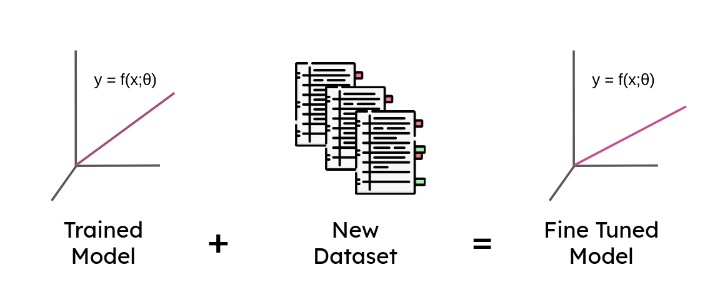

---

## **2.2. GPT con HuggingFace**

https://huggingface.co/learn/llm-course/chapter7/6


Hasta ahora hemos visto cómo crear y usar redes neuronales con Keras. Sin embargo, en temas de IA Gen se ha popularizado una librería que permite usar LLMs ya creados sin necesidad de entrenarlos y programarlos. Esta librería se llama HuggingFace

### Tokenizador

Descargamos el tokenizador ya preentrenado

In [ ]:
from transformers import AutoTokenizer

# Configure model and tokenizer
model_name = "HuggingFaceTB/SmolLM2-135M"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/704 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

### Modelo


In [ ]:
import torch
from transformers import AutoModelForCausalLM

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.config.pad_token_id = tokenizer.eos_token_id

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

In [ ]:
model.eval()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 576)
    (layers): ModuleList(
      (0-29): 30 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=576, out_features=576, bias=False)
          (k_proj): Linear(in_features=576, out_features=192, bias=False)
          (v_proj): Linear(in_features=576, out_features=192, bias=False)
          (o_proj): Linear(in_features=576, out_features=576, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=576, out_features=1536, bias=False)
          (up_proj): Linear(in_features=576, out_features=1536, bias=False)
          (down_proj): Linear(in_features=1536, out_features=576, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((576,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((576,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((576,), eps=1e-05)
    (rotary_emb): Lla

### Generación

In [ ]:
def generar_texto(
    prompt,
    max_length=100,
    temperature=0.8,
    top_k=50,
    top_p=0.95,
):

    # Tokeniza prompt
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,        # pad al batch si hay varios prompts
        truncation=True,
    )

    # Genera con el modelo
    output_ids = model.generate(
        input_ids=inputs["input_ids"].to(device),
        attention_mask=inputs["attention_mask"].to(device),
        max_length=max_length + inputs["input_ids"].shape[1],
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
        do_sample=True,
        pad_token_id=tokenizer.pad_token_id,
    )

    # Decodifica el resultado
    text = tokenizer.decode(output_ids[0], skip_special_tokens=False)
    return text

In [ ]:
prompt = "Who is the author of 100 years of solitude?"
texto_generado = generar_texto(prompt, max_length=150)
print(texto_generado)

Who is the author of 100 years of solitude?

(A) A new writer whose work has become so widely read that people are not sure it is original.)

(B) A writer who has published 100 books in a year. He has become a celebrity. A lot of people have written to him.

(C) A writer who has published 100 books in a year. He has made 1000,000 visits to the Internet, and he has become the most popular writer in the country.

(D) A writer who has published 100 books in a year. He has made more than 1000,000 visits to the Internet. He has made 10


---

## **2.3. Finetuning con Hugging Face**

https://huggingface.co/learn/llm-course/en/chapter11/3

### Dataset

Descargamos el dataset

In [ ]:
from datasets import load_dataset

# Load dataset
dataset = load_dataset("PiyushLavaniya/Small-Instruction-tuning-dataset")

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['question', 'answer', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 247
    })
    test: Dataset({
        features: ['question', 'answer', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 28
    })
})

In [ ]:
dataset["train"].to_pandas()

,question,answer,input_ids,attention_mask,labels
0,"#### Question:\nOMG, have you tried that new t...",Yes! Trendy desserts are an adventure for the ...,"[1835, 19782, 27, 187, 8262, 627, 13, 849, 434...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1835, 19782, 27, 187, 8262, 627, 13, 849, 434..."
1,#### Question:\nI need some new hairstyle idea...,"How about beachy waves, braids, or a cute top ...","[1835, 19782, 27, 187, 8262, 627, 13, 849, 434...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1835, 19782, 27, 187, 8262, 627, 13, 849, 434..."
2,#### Question:\nI have a sweet tooth. What's y...,Chocolate lava cake with a scoop of vanilla ic...,"[1835, 19782, 27, 187, 8262, 627, 13, 849, 434...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1835, 19782, 27, 187, 8262, 627, 13, 849, 434..."
3,#### Question:\nI'm thinking of going on a sol...,Solo adventures are empowering and perfect for...,"[1835, 19782, 27, 187, 8262, 627, 13, 849, 434...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1835, 19782, 27, 187, 8262, 627, 13, 849, 434..."
4,#### Question:\nI need a good book recommendat...,How about a romance novel or a thrilling myste...,"[1835, 19782, 27, 187, 8262, 627, 13, 849, 434...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1835, 19782, 27, 187, 8262, 627, 13, 849, 434..."
...,...,...,...,...,...
242,#### Question:\nShould I start a blog about my...,"Go for it! Share your style, inspire others, a...","[1835, 19782, 27, 187, 8262, 627, 13, 849, 434...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1835, 19782, 27, 187, 8262, 627, 13, 849, 434..."
243,#### Question:\nAre you into makeup and beauty...,"Absolutely! I love makeup, especially experime...","[1835, 19782, 27, 187, 8262, 627, 13, 849, 434...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1835, 19782, 27, 187, 8262, 627, 13, 849, 434..."
244,#### Question:\nI can't decide between a city ...,Why choose? Start with city exploration and en...,"[1835, 19782, 27, 187, 8262, 627, 13, 849, 434...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1835, 19782, 27, 187, 8262, 627, 13, 849, 434..."
245,#### Question:\nI'm into photography. What's y...,"Nature, sunsets, and candid moments capture th...","[1835, 19782, 27, 187, 8262, 627, 13, 849, 434...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1835, 19782, 27, 187, 8262, 627, 13, 849, 434..."


**Preprocess**

In [ ]:
def preprocess(sample):
    texts = []
    for inst, answer in zip(sample["question"], sample["answer"]):
        prompt = f"{inst}\n\n### RESPONSE ###\n".replace("#### Question:", "### QUESTION ###")
        text = prompt + answer
        texts.append(text)
    # Tokenizamos todas las secuencias pero sin padding
    return {"text":texts}


dataset_preprocessed = dataset.map(preprocess, batched=True, remove_columns=dataset["train"].column_names)
dataset_preprocessed["train"].to_pandas()

Map:   0%|          | 0/247 [00:00<?, ? examples/s]

Map:   0%|          | 0/28 [00:00<?, ? examples/s]

,text
0,"### QUESTION ###\nOMG, have you tried that new..."
1,### QUESTION ###\nI need some new hairstyle id...
2,### QUESTION ###\nI have a sweet tooth. What's...
3,### QUESTION ###\nI'm thinking of going on a s...
4,### QUESTION ###\nI need a good book recommend...
...,...
242,### QUESTION ###\nShould I start a blog about ...
243,### QUESTION ###\nAre you into makeup and beau...
244,### QUESTION ###\nI can't decide between a cit...
245,### QUESTION ###\nI'm into photography. What's...


**Tokenize**

In [ ]:
def tokenize(sample):
    return tokenizer(
        sample["text"],
        truncation=True,
        padding=False,  # no pad individual
        max_length=256,
    )


dataset_tokenized= dataset_preprocessed.map(function=tokenize, batched=True)
dataset_tokenized["train"].to_pandas()

Map:   0%|          | 0/247 [00:00<?, ? examples/s]

Map:   0%|          | 0/28 [00:00<?, ? examples/s]

,text,input_ids,attention_mask
0,"### QUESTION ###\nOMG, have you tried that new...","[3757, 30348, 8242, 4171, 20749, 198, 9232, 55...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,### QUESTION ###\nI need some new hairstyle id...,"[3757, 30348, 8242, 4171, 20749, 198, 57, 737,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,### QUESTION ###\nI have a sweet tooth. What's...,"[3757, 30348, 8242, 4171, 20749, 198, 57, 457,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,### QUESTION ###\nI'm thinking of going on a s...,"[3757, 30348, 8242, 4171, 20749, 198, 57, 5248...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,### QUESTION ###\nI need a good book recommend...,"[3757, 30348, 8242, 4171, 20749, 198, 57, 737,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
...,...,...,...
242,### QUESTION ###\nShould I start a blog about ...,"[3757, 30348, 8242, 4171, 20749, 198, 20646, 3...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
243,### QUESTION ###\nAre you into makeup and beau...,"[3757, 30348, 8242, 4171, 20749, 198, 9215, 34...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
244,### QUESTION ###\nI can't decide between a cit...,"[3757, 30348, 8242, 4171, 20749, 198, 57, 416,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
245,### QUESTION ###\nI'm into photography. What's...,"[3757, 30348, 8242, 4171, 20749, 198, 57, 5248...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


### LoRA

LoRa es una técnica matemática muy común cuando se hace finetuning de LLMs. Consiste en modificar el modelo para que solo se actualizen algunos pesos del modelo y por lo tanto sea más rápido

In [ ]:
from peft import LoraConfig
from peft import get_peft_model
# 3) Add LoRA for efficient fine‑tuning
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
)

model = get_peft_model(model, lora_config)
model

PeftModel(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 576)
        (layers): ModuleList(
          (0-29): 30 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=576, out_features=576, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=576, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=576, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear(
               

### Train

**Hiperparameters**

In [ ]:
from transformers import TrainingArguments

# Configure trainer
training_args = TrainingArguments(
    output_dir="./SmolLM2-135M-Instruct-checkpoints",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    num_train_epochs=12,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    save_steps=10,
    report_to="none"
)

**Train**

In [ ]:
import os
from transformers import Trainer
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False  # MUY IMPORTANTE: causal LM
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_tokenized["train"],
    eval_dataset=dataset_tokenized["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
)

trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 0}.


Step,Training Loss
10,3.129713
20,2.572274
30,2.164104
40,1.842239
50,1.656971
60,1.547883
70,1.493380
80,1.461853
90,1.437472


TrainOutput(global_step=96, training_loss=1.8915755053361256, metrics={'train_runtime': 192.3499, 'train_samples_per_second': 15.409, 'train_steps_per_second': 0.499, 'total_flos': 117170763912576.0, 'train_loss': 1.8915755053361256, 'epoch': 12.0})

**Checkpoints**

In [ ]:
import os

model.save_pretrained("./SmolLM2-135M-Instruct")
tokenizer.save_pretrained("./SmolLM2-135M-Instruct")

print(os.listdir("./SmolLM2-135M-Instruct-checkpoints"))
print(os.listdir("./SmolLM2-135M-Instruct"))

['checkpoint-90', 'checkpoint-96', 'checkpoint-60', 'checkpoint-20', 'checkpoint-70', 'checkpoint-30', 'checkpoint-40', 'checkpoint-80', 'checkpoint-50', 'checkpoint-10']
['adapter_config.json', 'adapter_model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'README.md']


### Generación

In [ ]:
model_name = "./SmolLM2-135M-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/240 [00:00<?, ?it/s]

In [ ]:
def generar_texto(
    prompt,
    max_length=100,
    temperature=0.8,
    top_k=50,
    top_p=0.95,
):

    # Tokeniza prompt
    inputs = tokenizer(
        f"### QUESTION ###\n{prompt}\n\n### RESPONSE ###\n",
        return_tensors="pt",
        padding=True,        # pad al batch si hay varios prompts
        truncation=True,
    )

    # Genera con el modelo
    output_ids = model.generate(
        input_ids=inputs["input_ids"].to(device),
        attention_mask=inputs["attention_mask"].to(device),
        max_length=max_length + inputs["input_ids"].shape[1],
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
        do_sample=True,
        pad_token_id=tokenizer.pad_token_id,
    )

    # Decodifica el resultado
    text = tokenizer.decode(output_ids[0], skip_special_tokens=False)
    return text

In [ ]:
prompt = "Who is the author of 100 years of solitude?"
texto_generado = generar_texto(prompt, max_length=150)
print(texto_generado)

### QUESTION ###
Who is the author of 100 years of solitude?

### RESPONSE ###
Auntie Ruth. My mom and I shared this one-of-a-kind love for quietness and solitude. ✨🌱📚📺👸🏽👷👴🏽💁👸🏼👸🏽📺🧰📺👸🏽💁👸🏽📺🧰👸🏽📺🧰👸🏽💁👸🏽💁👸🏽👸🏽📺🧰📺�
